# **Árvores de Decisão**

#### **Definição**:

Árvores de decisão são modelos de aprendizado supervisionado que mapeiam escolhas e consequências em uma estrutura de fluxograma, hierarquizando perguntas sobre dados (nós) para prever resultados (folhas). Elas são valorizadas pela facilidade de interpretação, intuição visual e capacidade de lidar com dados numéricos ou categóricos.

#### **Vantagens**:
- Fácil de entender e interpretar.
- O custo de utilização da árvore (ou seja, de previsão dos dados) é logarítmico em relação ao número de pontos de dados utilizados para treinar a árvore.
- A explicação para uam tomada de decisão é facilmente explicada pela lógica booleana.


#### **Desvantagens**:
- Os algoritmos de aprendizado por árvore de decisão podem criar árvores excessivamente complexas que nãp generalizam bem os dados (árvores profundas). Isso é chamado de overfitting.
- Podem ser instáveis. Esse problema é atenuado pelo uso de árvores de decisão dentro de um conjunto (ensemble).


#### **Dilema Viés-Variância**

As árvores de decisão tem um problema:
- Se usarmos uma altura muito pequena, a capacidade não será suficiente para conseguir uma performance boa (`Underfitting`).
- Se usarmos uma altura muito grande, a capcidade será tão grande que o modelo irá memorizar os dados de treino, sem generalizar (`Overfitting`).

#### **Como resolver o dilema?**

Tradicionalmente, nós tentamos encontrar a altura 'perfeita' que equilibra o viés e a variância com um conjunto de validação, mas isso pode não funcionar tão bem. Nós temos outras possibilidades:
- Usar árvores de altura pequena e usar métodos que diminuem o viés (Boost).
- Usar árvores de altura alta e usar métodos que diminuem a variância (Bagging).

#### **Classificadores Enviesados**

São modelos que não possuem capacidade suficiente para modelar a função verdadeira (a aárvore de decisão com 1 nó é um exemplo).

Por se tratar de uma limitação inerente ao modelo, classificadores enviesados não conseguem uma acurácia boa mesmo quando a quantidade de dados aumenta:

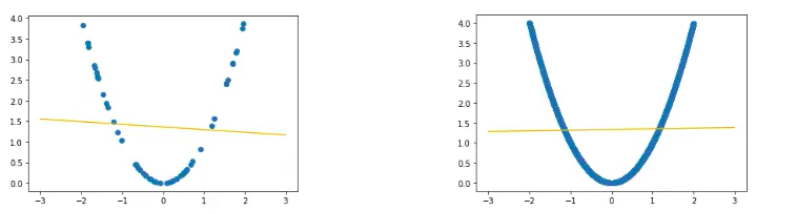


#### **Classificadores com alta variância**

São modelos que conseguem aprender (ou decorar) funções altamente complexas, muita vezes chegando até um erro de treino 0.

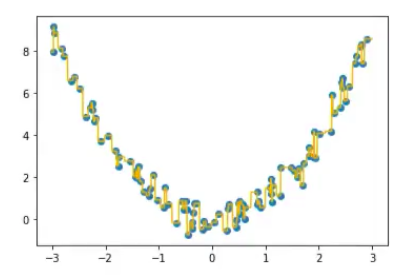

##### **Na prática, árvores de decisão são péssimas, mas são a base do `Bagging` e do `Boosting`.**

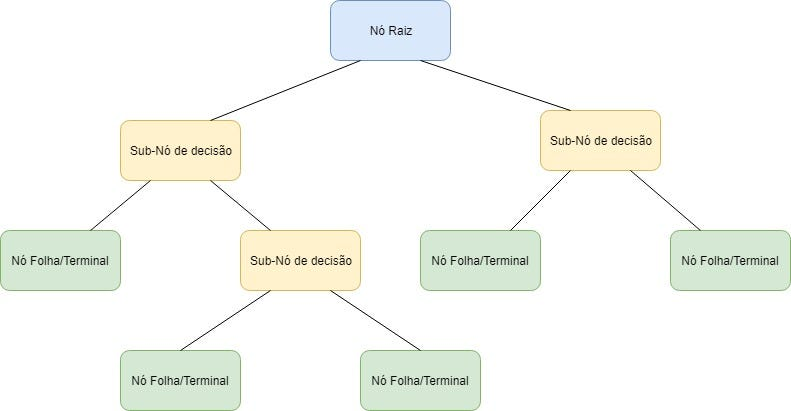

## **Exemplo de Classificação: Dataset Iris**

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### **Carregando o dataset**

In [2]:
iris = sns.load_dataset('iris')

iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
# Visualizando as classes:

classes = iris.species.unique()

classes

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [4]:
# Visualizando a distribuição dos dados

iris.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [5]:
# Verificando a existência de dados nulos:

iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
# Fazendo o label encoder nos dados

iris.species = iris.species.map({'setosa': 0, 'versicolor': 1, 'virginica': 2})

iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
# Visualizando as classes pós encoder:

iris.species.unique()

array([0, 1, 2])

### **Dividindo os dados em teste e treino**

In [8]:
X = np.array(iris.drop(columns='species'))

X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [9]:
y = np.array(iris.species)

y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'X_train shape = {X_train.shape}')
print(f'X_test shape = {X_test.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'y_test shape = {y_test.shape}')

X_train shape = (105, 4)
X_test shape = (45, 4)
y_train shape = (105,)
y_test shape = (45,)


### **Criando o modelo**

In [11]:
# Importando e instânciando o modelo
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(max_depth=3, criterion='gini')

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [12]:
feature_names = list(iris.columns)[:-1]
feature_names

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [13]:
class_names = list(classes)
class_names

['setosa', 'versicolor', 'virginica']

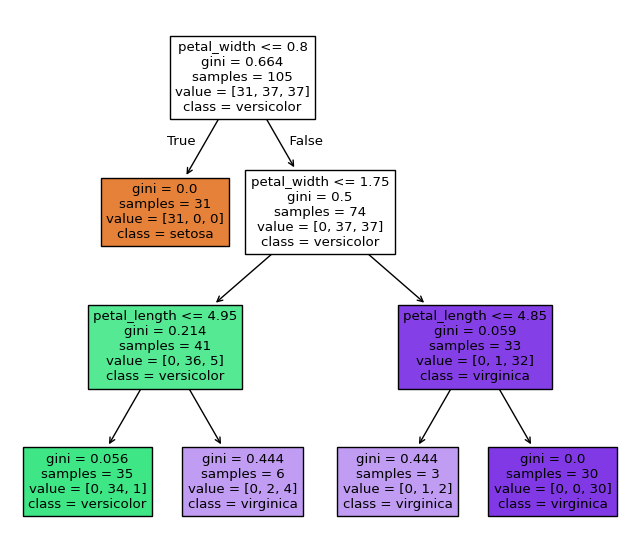

In [ ]:
plt.figure(figsize=(8,7))
plot_tree(model, class_names=class_names, feature_names=feature_names, filled=True, )
plt.show()

### **Avaliação do modelo**

In [15]:
from sklearn.metrics import accuracy_score, classification_report

predict_ = model.predict(X_test)
acc = accuracy_score(y_test, predict_)

In [16]:
print(f'accuracy = {acc:.4%}')

accuracy = 100.0000%


In [17]:
print(classification_report(y_test, predict_))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



#### **Referências**:
- https://scikit-learn.org/stable/modules/tree.html